In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress, t
from matplotlib.ticker import FormatStrFormatter

# Input files
systems = ["KI_NaCl", "GaP_GaAs", "GaN_Al2O3"]
titles = [r"KI/NaCl", r"GaP/GaAs", r"GaN/$\mathrm{Al_{2}O_{3}}$"]
mace_paths = [f"mace_results/{system}.csv" for system in systems]
dft_paths = [f"dft_results/{system}.csv" for system in systems]
# Column names
mace_energy_col = "mace_relaxed_energy"
dft_energy_col = "dft_relaxed_energy"
fgw_col = "fgw_distance_megn_050"
# Figure layout
fig_width = 7.2
fig_height = 4.5
fig_layout = dict(
    left=0.05,
    right=0.95,
    bottom=0.05,
    top=0.95,
    wspace=0.25,
    hspace=0.1,
)
# Plotting configuration
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
})
panel_label_size = 14
# Hexbin and histogram style
scatter_cmap = "Blues"
hex_gridsize = 12
hist_color = "#D3D8DC"
hist_edge = "#000000"
hist_bins = 24
hist_ratio = 0.18
# Scatter and fitting style
point_color = "#3F6C88"
point_size = 18
ci_color = "#D3D3D3"
fit_color = "#000000"

In [2]:
def fit_linear_with_ci(xi, yi, confidence=0.95, n_grid=200):
    xi= np.asarray(xi, dtype=float)
    yi = np.asarray(yi, dtype=float)
    fit = linregress(xi, yi)
    x_fit = np.linspace(xi.min(), xi.max(), n_grid)
    y_fit = fit.slope * x_fit + fit.intercept
    n = len(xi)
    x_mean = np.mean(xi)
    sxx = np.sum((xi-x_mean) ** 2)
    y_pred = fit.intercept + fit.slope * xi
    resids = yi - y_pred
    s_err = np.sqrt(np.sum(resids**2) / (n-2))
    t_crit = t.ppf((1.0+confidence)/2.0, df=n-2)
    se_mean = s_err * np.sqrt(1.0/n+(x_fit-x_mean)**2/sxx)
    ci = t_crit * se_mean
    y_lower = y_fit - ci
    y_upper = y_fit + ci
    return x_fit, y_fit, y_lower, y_upper

In [3]:
mace_data = []
dft_data = []

for system, title, mace_path in zip(systems, titles, mace_paths):
    df = pd.read_csv(mace_path).copy()
    # Convert absolute values to relative values for better visualization
    df["relative_distance"] = df[fgw_col] - df[fgw_col].min()
    df["relative_energy"] = df[mace_energy_col] - df[mace_energy_col].min()
    x = df["relative_distance"].to_numpy(dtype=float)
    y = df["relative_energy"].to_numpy(dtype=float)
    r = float(pearsonr(x, y).statistic)
    rho = float(spearmanr(x, y).statistic)
    mace_data.append((title, x, y, r, rho))

for system, title, dft_path in zip(systems, titles, dft_paths):
    df = pd.read_csv(dft_path).copy()
    df["relative_distance"] = df[fgw_col] - df[fgw_col].min()
    df["relative_energy"] = df[dft_energy_col] - df[dft_energy_col].min()
    x = df["relative_distance"].to_numpy(dtype=float)
    y = df["relative_energy"].to_numpy(dtype=float)
    r = float(pearsonr(x, y).statistic)
    rho = float(spearmanr(x, y).statistic)
    dft_data.append((title, x, y, r, rho))

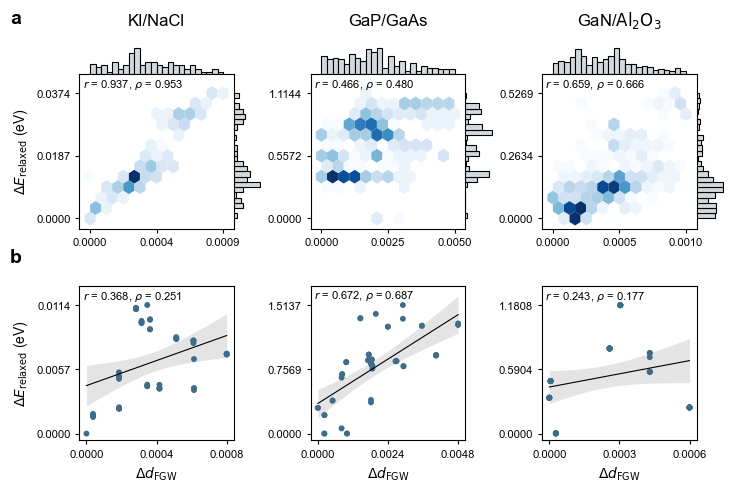

In [4]:
fig = plt.figure(figsize=(fig_width, fig_height))
outer = fig.add_gridspec(
    2, 3,
    left=fig_layout["left"],
    right=fig_layout["right"],
    bottom=fig_layout["bottom"],
    top=fig_layout["top"],
    wspace=fig_layout["wspace"],
    hspace=fig_layout["hspace"],
)
# Set axes containers
axes_main = np.empty((2, 3), dtype=object)
axes_histx = np.empty(3, dtype=object)
axes_histy = np.empty(3, dtype=object)

# Row 1: hexbin with marginal histograms
for col_idx in range(3):
    title, x, y, r, rho = mace_data[col_idx]
    inner = outer[0, col_idx].subgridspec(2, 2, height_ratios=[1.0, 5.0], width_ratios=[5.0, 1.0], hspace=0.0, wspace=0.0)
    # Add axes
    ax_histx = fig.add_subplot(inner[0, 0])
    ax = fig.add_subplot(inner[1, 0], sharex=ax_histx)
    ax_histy = fig.add_subplot(inner[1, 1], sharey=ax)
    axes_main[0, col_idx] = ax
    axes_histx[col_idx] = ax_histx
    axes_histy[col_idx] = ax_histy
    # Draw main hexbin plot
    ax.set_box_aspect(1)
    ax.hexbin(x, y, gridsize=hex_gridsize, cmap=scatter_cmap, mincnt=1, linewidths=0)
    corr_label = rf"$r$ = {r:.3f}, $\rho$ = {rho:.3f}"
    ax.text(0.02, 0.98, corr_label, transform=ax.transAxes, ha="left", va="top")
    ax.tick_params(direction="out", length=3, width=0.8, top=False, right=False)
    ax.set_xticks(np.linspace(x.min(), x.max(), 3))
    ax.set_yticks(np.linspace(y.min(), y.max(), 3))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.4f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
    ax.set_ylim(y.min()-0.08*(y.max()-y.min()), y.max()+0.15*(y.max()-y.min()))
    ax.set_xlim(x.min()-0.08*(x.max()-x.min()), x.max()+0.08*(x.max()-x.min()))
    if col_idx == 0:
        ax.set_ylabel(r"$\Delta E_{\mathrm{relaxed}}$ (eV)")
    # Draw marginal histograms
    ax_histx.hist(x, bins=hist_bins, color=hist_color, edgecolor=hist_edge, linewidth=0.8)
    ax_histx.axis("off")
    ax_histy.hist(y, bins=hist_bins, orientation="horizontal", color=hist_color, edgecolor=hist_edge, linewidth=0.8)
    ax_histy.axis("off")
     # Add title
    ax_histx.set_title(title, pad=15)
    fig.canvas.draw()
    ax_pos = ax.get_position()
    ax_histx.set_position((ax_pos.x0, ax_pos.y1, ax_pos.width, ax_pos.height*hist_ratio))
    ax_histy.set_position((ax_pos.x1, ax_pos.y0, ax_pos.width*hist_ratio, ax_pos.height))

# Row 2: scatter with linear fit and CI
for col_idx in range(3):
    title, x, y, r, rho = dft_data[col_idx]
    ax = fig.add_subplot(outer[1, col_idx])
    axes_main[1, col_idx] = ax
    ax.set_box_aspect(1)
    ax.scatter(x, y, s=point_size, color=point_color, edgecolors="none", zorder=2)
    x_fit, y_fit, y_lower, y_upper = fit_linear_with_ci(x, y)
    ax.fill_between(x_fit, y_lower, y_upper, color=ci_color, alpha=0.6, linewidth=0, zorder=1)
    ax.plot(x_fit, y_fit, color=fit_color, linewidth=0.8, zorder=3)
    corr_label = rf"$r$ = {r:.3f}, $\rho$ = {rho:.3f}"
    ax.text(0.02, 0.98, corr_label, transform=ax.transAxes, ha="left", va="top")
    ax.tick_params(direction="out", length=3, width=0.8, top=False, right=False)
    ax.set_ylim(y.min()-0.05*(y.max()-y.min()), y.max()+0.15*(y.max()-y.min()))
    ax.set_xlim(x.min()-0.05*(x.max()-x.min()), x.max()+0.05*(x.max()-x.min()))
    ax.set_xticks(np.linspace(x.min(), x.max(), 3))
    ax.set_yticks(np.linspace(y.min(), y.max(), 3))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.4f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
    ax.set_xlabel("$\Delta d_{\mathrm{FGW}}$")
    if col_idx == 0:
        ax.set_ylabel(r"$\Delta E_{\mathrm{relaxed}}$ (eV)")

# Add row labels
axes_main[0, 0].text(
    -0.45, 1.33,
    "a",
    transform=axes_main[0, 0].transAxes,
    fontsize=panel_label_size,
    fontweight="bold",
)
axes_main[1, 0].text(
    -0.45, 1.15,
    "b",
    transform=axes_main[1, 0].transAxes,
    fontsize=panel_label_size,
    fontweight="bold",
)
# Align row 2 to row 1 main axes
fig.canvas.draw()

for col_idx in range(3):
    ref_ax = axes_main[0, col_idx]
    ax = axes_main[1, col_idx]
    ref_pos = ref_ax.get_position()
    ax_pos = ax.get_position()
    ax.set_position((ref_pos.x0, ax_pos.y0, ref_pos.width, ref_pos.height))

# Output files
plt.savefig("fgw_relaxed_correlation.pdf", dpi=300, bbox_inches="tight")
plt.show()